# Machine Learning Jump-Start Workbook

Let's build a basic machine learning model. First thing's first; we need to
import the packages we need - specifically, PyTorch.
Documentation can be found at https://docs.pytorch.org/docs/stable/index.html

### Install relevant python packages via pip (only uncomment and run if these are necessary)

In [6]:
# !python -m pip install torch torchvision tqdm matplotlib

In [7]:
import torch

Using PyTorch, we can generate practically any model we would like to. PyTorch is very powerful, as you have full control over every component of the network, while wrapping together many useful components.

To start, we can make a very simple 2-layer network.

In [8]:
linear_layer = torch.nn.Linear(28*28, 100, bias=True)

In [9]:
linear_layer.weight.shape

torch.Size([100, 784])

In [10]:
class SimpleModel(torch.nn.Module):
  def __init__(self, input_size, output_size):
    super(SimpleModel, self).__init__()
    self.layer1 = torch.nn.Linear(input_size, 100, bias=True)
    self.layer2 = torch.nn.Linear(100, output_size, bias=True)
    self.activation = torch.nn.ReLU()

In [11]:
model = SimpleModel(28*28, 10)
print(model)

SimpleModel(
  (layer1): Linear(in_features=784, out_features=100, bias=True)
  (layer2): Linear(in_features=100, out_features=10, bias=True)
  (activation): ReLU()
)


In [12]:
model.layer1.weight.shape

torch.Size([100, 784])

In [13]:
model.layer2.bias

Parameter containing:
tensor([-0.0789,  0.0336,  0.0025, -0.0157, -0.0956,  0.0972,  0.0759, -0.0544,
        -0.0691,  0.0206], requires_grad=True)

## Setting up the dataset - MNIST

In [7]:
from torchvision.datasets import MNIST

In [8]:
from torchvision.transforms import ToTensor
train_dataset = MNIST(train=True, root='data/', download=True, transform=ToTensor())
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 300kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.7MB/s]


2
torch.Size([128, 1, 28, 28])
torch.Size([128])
tensor(7)


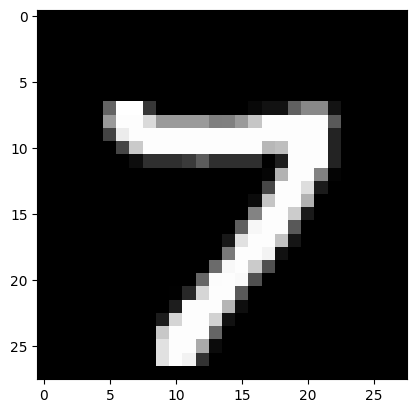

In [28]:
# Let's get a single sample
samples = next(iter(train_dataloader))
print(len(samples))
print(samples[0].shape)
print(samples[1].shape)

# Take a look at the input
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(samples[0][0][0], cmap='grey')
print(samples[1][0])

## Let's add in the logic for a forward pass!

In [31]:
class SimpleModel(torch.nn.Module):
  def __init__(self, input_size, output_size):
    super(SimpleModel, self).__init__()
    self.layer1 = torch.nn.Linear(input_size, 100, bias=True)
    self.layer2 = torch.nn.Linear(100, output_size, bias=True)
    self.activation = torch.nn.ReLU()

  def forward(self, X):
    y = self.layer1(X)
    y = self.activation(y)
    y = self.layer2(y)
    y = self.activation(y)
    return y

model = SimpleModel(28*28, 10)

## Let's try to make some predictions with our new model!

In [42]:
samples = next(iter(train_dataloader))
X = samples[0]
y = samples[1]
X = X.view(-1, 28*28)
predictions = model(X)
predicted_class = torch.argmax(predictions, dim=1)

In [47]:
# Take a look at some predictions, and check our model's performance
print(f'First sample class label: {y[0]}; first sample predicted class: {predicted_class[0]}')

# Let's observe our accuracy for this batch of samples
correct_predictions = torch.where(predicted_class == y, 1, 0)
accuracy = sum(correct_predictions) / len(y)
print(f'Accuracy: {accuracy}')


First sample class label: 0; first sample predicted class: 4
Accuracy: 0.078125
